<a href="https://colab.research.google.com/github/reedlm11/INFO648/blob/main/INFO_648_Summer26_HW3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                        INFO 648 — Homework problem set 3
                                                        Inference with Winsorized Weekly
                                                        Earnings by Sex (2024 vs. 2025)
                                                        By: Lae'sha Reed
                                                        6/2/2026

In [53]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt



# Load the dataset (assuming the same path as before)
df = pd.read_csv('/content/cps_with_education-1 (1) (1).csv')

# Display initial data to verify load
print("Original DataFrame head:")
display(df.head())

Original DataFrame head:


,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,0,2020,40,0.0,63,2,23,Some College
1,1,2020,999,0.0,67,1,23,Some College
2,2,2020,48,654.0,64,1,23,Some College
3,3,2020,999,0.0,71,2,23,Less than HS
4,4,2020,44,0.0,54,2,23,Some College


In [42]:
# Keep only 2024 and 2025
df = df[df["YEAR"].isin([2024, 2025])]

# Remove invalid earnings
df = df[(df["EARNWEEK2"] > 0) & (df["EARNWEEK2"] != 999999.99)]

In [44]:
men_2024 = df[(df["SEX"] == 1) & (df["YEAR"] == 2024)]
men_2025 = df[(df["SEX"] == 1) & (df["YEAR"] == 2025)]
women_2024 = df[(df["SEX"] == 2) & (df["YEAR"] == 2024)]
women_2025 = df[(df["SEX"] == 2) & (df["YEAR"] == 2025)]

**Part A — Winsorization (Outlier Handling)**

In [77]:



# cutoff at 95th percentile

men_2024_cut = results["Men-2024"]["data"].quantile(.95)
men_2025_cut = results["Men-2025"]["data"].quantile(.95)
women_2024_cut = results["Women-2024"]["data"].quantile(.95)
women_2025_cut = results["Women-2025"]["data"].quantile(.95)

print(men_2024_cut, men_2025_cut, women_2024_cut, women_2025_cut)

3660.0 3860.0 2880.0 2972.79999999986


In [82]:
results["Men-2024"]["data"] = np.minimum(results["Men-2024"]["data"], men_2024_cut)
results["Men-2025"]["data"] = np.minimum(results["Men-2025"]["data"], men_2025_cut)
results["Women-2024"]["data"] = np.minimum(results["Women-2024"]["data"], women_2024_cut)
results["Women-2025"]["data"] = np.minimum(results["Women-2025"]["data"], women_2025_cut)

In [83]:
pd.DataFrame({
    "Group": ["Men-2024", "Men-2025", "Women-2024", "Women-2025"],
    "95th Percentile Cutoff": [
        men_2024_cut,
        men_2025_cut,
        women_2024_cut,
        women_2025_cut
    ],
    "Sample Size": [
        len(men_2024),
        len(men_2025),
        len(women_2024),
        len(women_2025)
    ]
})

,Group,95th Percentile Cutoff,Sample Size
0,Men-2024,3660.0,66587
1,Men-2025,3860.0,55953
2,Women-2024,2880.0,64001
3,Women-2025,2972.8,53705


**Part B — Confidence Intervals for Population Mean Earnings**

In [84]:


z = norm.ppf(1 - 0.025)
print(z)

1.959963984540054


In [85]:
n = len(results["Men-2024"]["data"])
mean_earn = np.mean(results["Men-2024"]["data"])
std_earn = np.std(results["Men-2024"]["data"], ddof=1)

print(n, mean_earn, std_earn)

ci_lower = mean_earn - z * std_earn / np.sqrt(n)
ci_upper = mean_earn + z * std_earn / np.sqrt(n)

print(ci_lower, ci_upper)

66587 1411.7721451634702 915.0637489384089
1404.82182649212 1418.7224638348205


In [86]:
n = len(results["Men-2025"]["data"])
mean_earn = np.mean(results["Men-2025"]["data"])
std_earn = np.std(results["Men-2025"]["data"], ddof=1)

print(n, mean_earn, std_earn)

ci_lower = mean_earn - z * std_earn / np.sqrt(n)
ci_upper = mean_earn + z * std_earn / np.sqrt(n)

print(ci_lower, ci_upper)

55953 1483.1847014458563 979.2960965407782
1475.0704132963563 1491.2989895953563


In [87]:
n = len(results["Women-2024"]["data"])
mean_earn = np.mean(results["Women-2024"]["data"])
std_earn = np.std(results["Women-2024"]["data"], ddof=1)

print(n, mean_earn, std_earn)

ci_lower = mean_earn - z * std_earn / np.sqrt(n)
ci_upper = mean_earn + z * std_earn / np.sqrt(n)

print(ci_lower, ci_upper)

64001 1091.9312173247295 722.1363658733335
1086.3365543801785 1097.5258802692804


In [88]:
n = len(results["Women-2025"]["data"])
mean_earn = np.mean(results["Women-2025"]["data"])
std_earn = np.std(results["Women-2025"]["data"], ddof=1)

print(n, mean_earn, std_earn)

ci_lower = mean_earn - z * std_earn / np.sqrt(n)
ci_upper = mean_earn + z * std_earn / np.sqrt(n)

print(ci_lower, ci_upper)

53705 1128.5500865841097 748.5595196648406
1122.2191630459877 1134.8810101222318


A 95% confidence interval shows the range where the true average weekly earnings for each group is likely to fall.

For men the 2024 interval (1404.82, 1418.72) and the 2025 interval (1475.07, 1491.30) do not overlap which indicates an increase in mean earnings from 2024 to 2025.

For women the 2024 interval (1086.34, 1097.53) and the 2025 interval (1122.22, 1134.88) also do not overlap indicating earnings increased over time as well. In summary, both groups show higher average weekly earnings in 2025 compared to 2024 while still reflecting the uncertainty in the estimates.

**Part C — Hypothesis Tests: Did the Population Mean Change?**

In [90]:
from scipy.stats import ttest_ind

In [91]:
men_tstat, men_pvalue = ttest_ind(
    results["Men-2025"]["data"],
    results["Men-2024"]["data"],
    equal_var=False
)

print(men_tstat, men_pvalue)


women_tstat, women_pvalue = ttest_ind(
    results["Women-2025"]["data"],
    results["Women-2024"]["data"],
    equal_var=False
)

print(women_tstat, women_pvalue)

13.100484941263966 3.48876568606699e-39
8.494976355198219 2.0033677421942506e-17


the null hypothesis is rejected at a = 0.05 Because both men and women have p-values below 0.05 this means there are significant differences in average weekly earnings between 2024 and 2025.

The population's mean weekly earnings increased from 2024 to 2025 for both groups based on the sample data.


**Part D — Statistical vs. Practical Significance**

In [92]:
x1 = results["Men-2024"]["data"]
x2 = results["Men-2025"]["data"]

n1, n2 = len(x1), len(x2)
s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))

mean1 = np.mean(x1)
mean2 = np.mean(x2)

d_men = (mean2 - mean1) / sp
pct_men = ((mean2 - mean1) / mean1) * 100

print(d_men, pct_men)

0.07557406770708039 5.058362748339756


In [93]:
x1 = results["Women-2024"]["data"]
x2 = results["Women-2025"]["data"]

n1, n2 = len(x1), len(x2)
s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))

mean1 = np.mean(x1)
mean2 = np.mean(x2)

d_women = (mean2 - mean1) / sp
pct_women = ((mean2 - mean1) / mean1) * 100

print(d_women, pct_women)

0.04986839058533363 3.3535875408982103


For men Cohen’s d is 0.076 which is a very small effect size. For women it is 0.050, which is also very small. This shows that even though there are differences in average earnings between 2024 and 2025, the actual size of the difference is small compared to the variation in earnings. The p-values are still extremely small because the sample size is large, so even small differences show up as statistically significant. This shows the difference is significant but not too large in real-world terms.


**Part E — CPI Check: Are Earnings “Keeping Up”?**

In [94]:
cpi = 2.7

print("Men:", pct_men, "vs CPI:", cpi)
print("Women:", pct_women, "vs CPI:", cpi)

Men: 5.058362748339756 vs CPI: 2.7
Women: 3.3535875408982103 vs CPI: 2.7


Women’s increased by 3.36% while men’s weekly earnings increased by 5.06%. Both groups are staying in line with the 2.7% CPI increase in this sample since their earnings growth is higher than inflation, but men experienced a slightly higher increase than women, pointing to stronger earnings growth over this time period.

These results come from sample means and winsorized data, so they be different depending on the sample and don’t capture every individual’s experience.

**PART F — PLOTS**

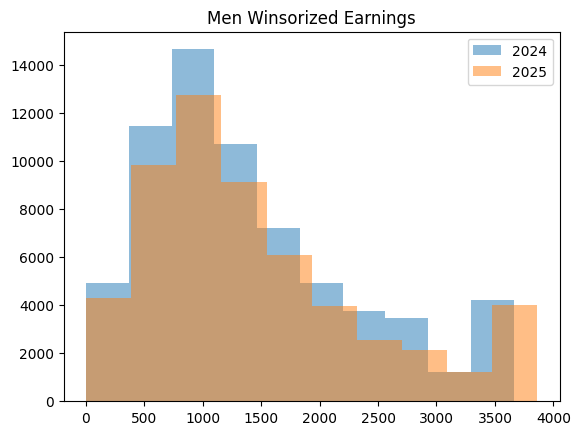

In [72]:
plt.figure()
plt.hist(results["Men-2024"]["data"], alpha=0.5, label="2024")
plt.hist(results["Men-2025"]["data"], alpha=0.5, label="2025")
plt.title("Men Winsorized Earnings")
plt.legend()
plt.show()

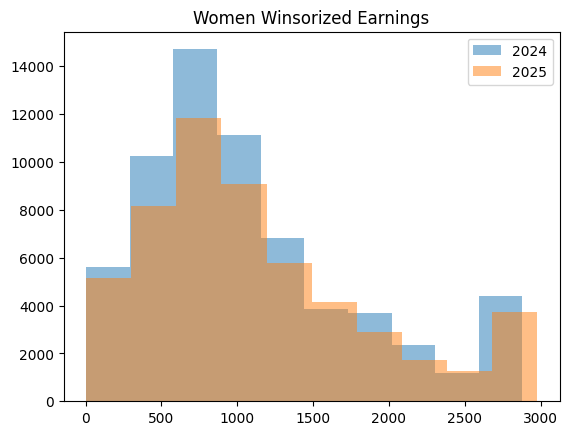

In [51]:
plt.figure()
plt.hist(results["Women-2024"]["data"], alpha=0.5, label="2024")
plt.hist(results["Women-2025"]["data"], alpha=0.5, label="2025")
plt.title("Women Winsorized Earnings")
plt.legend()
plt.show()

Both plots show that earnings are skewed to the right with most values concentrated in the lower-to-middle range and a long tail of higher earnings. The charts also show a large amount of overlap between 2024 and 2025, suggesting the main difference between the years is a slight shift in the overall distribution

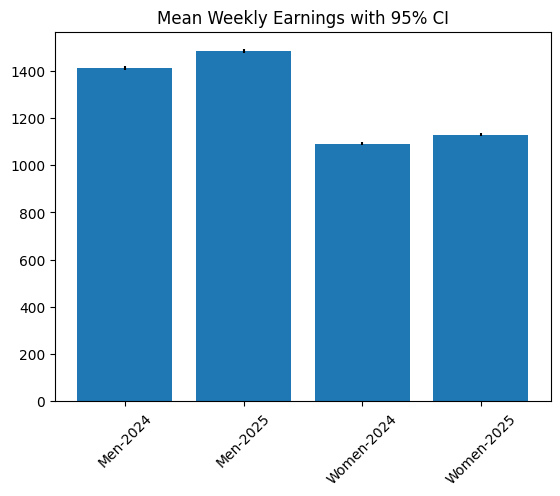

In [52]:
# Mean + CI Plot

labels = []
means = []
errors = []

for name, r in results.items():
    m, (low, high) = ci(r["data"])
    labels.append(name)
    means.append(m)
    errors.append(high - m)

plt.figure()
plt.bar(labels, means, yerr=errors)
plt.xticks(rotation=45)
plt.title("Mean Weekly Earnings with 95% CI")
plt.show()